In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.interpolate import CubicSpline

In [3]:
a, b = -2, 2
n, N = 5, 500
x = np.linspace(a, b, n)
X = np.linspace(a, b, N)

In [4]:
f = lambda x: np.cos(x)*(1/(x+3))
df = lambda x: -np.sin(x)*(1/(x+3)) - np.cos(x)*(1/x**2)

In [5]:
f = lambda x: (1/32)*x**4 + 5*x**3 + 6*x + 70
df = lambda x: (1/8)*x**3 + 15*x**2 + 6

In [6]:
y = f(x)
Y = f(X)
dy = df(x)
dY = df(X)

## Splines
mit scipy:

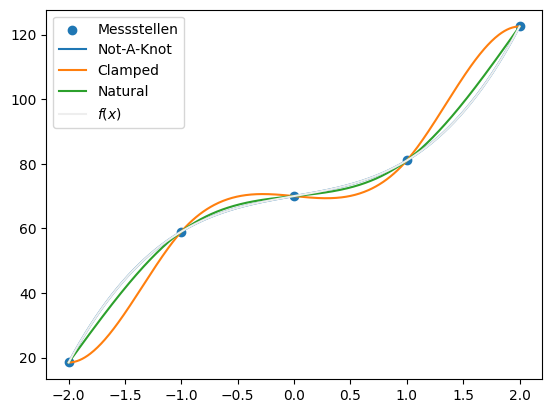

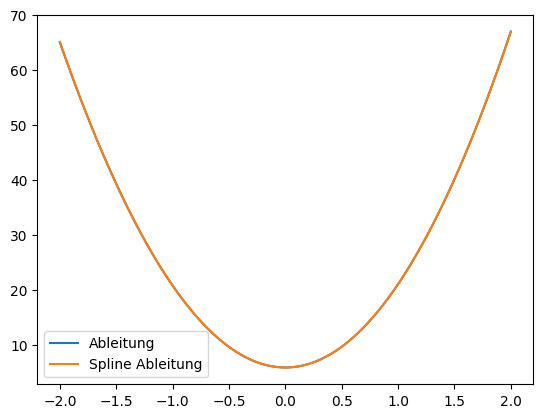

In [ ]:
cs = CubicSpline(x, y)
cs_clamped = CubicSpline(x, y, bc_type="clamped") # ((1, df(a)), (1, df(b))) als bc_type für korrekt eingespannt
cs_natural = CubicSpline(x, y, bc_type="natural")

plt.scatter(x, y, label="Messstellen")
plt.plot(X, cs(X), label="Not-A-Knot")
plt.plot(X, cs_clamped(X), label="Clamped")
plt.plot(X, cs_natural(X), label="Natural")
plt.plot(X, Y, label=r"$f(x)$", color="#eeeeee")
plt.legend()
plt.show()

plt.plot(X, dY, label="Ableitung")
plt.plot(X, cs(X, 1), label="Spline Ableitung")
plt.legend()

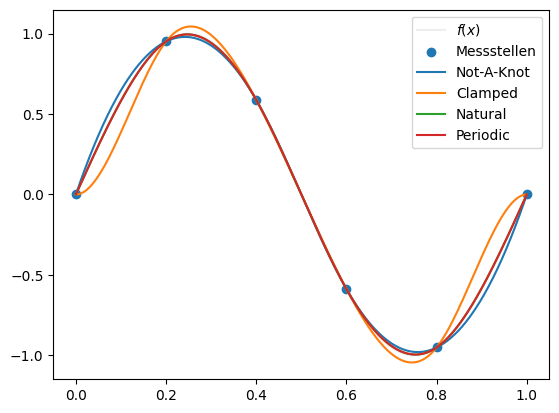

In [8]:

g = lambda t: np.sin(2 * np.pi * t)
dg = lambda t: 2*np.pi*np.cos(2*np.pi*t)

xg = np.linspace(0, 1, (n+1), endpoint=True)
Xg = np.linspace(0, 1, (N+1), endpoint=True)
yg = g(xg)
Yg = g(Xg)

cs_g = CubicSpline(xg, yg)
cs_clamped_g = CubicSpline(xg, yg, bc_type="clamped") #((1, dg(x[0])), (1, dg(x[-1]))))
cs_natural_g = CubicSpline(xg, yg, bc_type="natural")
cs_periodic_g = CubicSpline(xg, yg, bc_type="periodic")

plt.plot(Xg, Yg, label=r"$f(x)$", color="#eeeeee")
plt.scatter(xg, yg, label="Messstellen")
plt.plot(Xg, cs_g(Xg), label="Not-A-Knot")
plt.plot(Xg, cs_clamped_g(Xg), label="Clamped")
plt.plot(Xg, cs_natural_g(Xg), label="Natural")
plt.plot(Xg, cs_periodic_g(Xg), label="Periodic")
plt.legend()